# Hybrid RRF without Flat — Charts

This notebook plots NDCG@K and Recall@K for the no-Flat Hybrid RRF configuration.


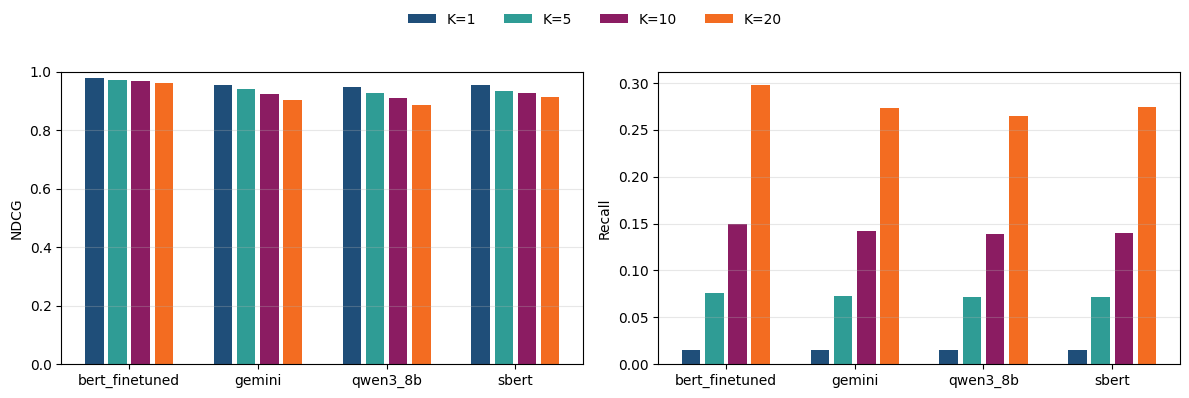

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Hybrid RRF without Flat — chart generation
# Flat is excluded from the hybrid fusion and retained
# only as the exact-search baseline in the paper.
# =====================================================

XLSX = "hybrid_rrf_no_flat_summary.xlsx"
SHEET = "Summary"

K_LIST = [1, 5, 10, 20]
TARGET_METRIC = "cosine"

if not os.path.exists(XLSX):
    raise FileNotFoundError(
        f"{XLSX} not found. First run Hybrid1_Reciprocal_Rank_Fusion_NoFlat.ipynb "
        "to generate the no-Flat hybrid results."
    )

# Read results
df = pd.read_excel(XLSX, sheet_name=SHEET, engine="openpyxl")

# Cosine only
df = df[df["metric"].astype(str).str.lower() == TARGET_METRIC].copy()
df["K"] = df["K"].astype(int)
df = df[df["K"].isin(K_LIST)]

# Pivot tables
pivot_ndcg = df.pivot_table(
    index="embedding",
    columns="K",
    values="ndcg@K",
    aggfunc="mean"
).sort_index()

pivot_recall = df.pivot_table(
    index="embedding",
    columns="K",
    values="recall@K",
    aggfunc="mean"
).sort_index()

embeddings = pivot_ndcg.index.tolist()
x = np.arange(len(embeddings))
bar_w = 0.18

# Colors consistent with previous figures
colors = ["#1f4e79", "#2f9c95", "#8b1c62", "#f36c21"]

# Figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---------- NDCG ----------
ax = axes[0]
for j, K in enumerate(K_LIST):
    ax.bar(
        x + (j - (len(K_LIST) - 1) / 2) * bar_w,
        pivot_ndcg[K].values,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )

# ax.set_title("Hybrid RRF without Flat — NDCG@K")
ax.set_ylabel("NDCG")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

# ---------- Recall ----------
ax = axes[1]
for j, K in enumerate(K_LIST):
    ax.bar(
        x + (j - (len(K_LIST) - 1) / 2) * bar_w,
        pivot_recall[K].values,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )

# ax.set_title("Hybrid RRF without Flat — Recall@K")
ax.set_ylabel("Recall")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")
ax.grid(axis="y", alpha=0.3)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()


In [ ]:
# Save high-resolution figure for the paper
FIG_NAME = "Hybrid1_RRF_NoFlat_NDCG_Recall_cosine.png"
PDF_NAME = "Hybrid1_RRF_NoFlat_NDCG_Recall_cosine.pdf"

fig.savefig(FIG_NAME, dpi=600, bbox_inches="tight")
fig.savefig(PDF_NAME, bbox_inches="tight")

print("Figure saved as:", FIG_NAME)
print("PDF saved as:", PDF_NAME)


✅ Figure saved as: Hybrid1_RRF_NoFlat_NDCG_Recall_cosine.png
✅ PDF saved as: Hybrid1_RRF_NoFlat_NDCG_Recall_cosine.pdf


Script 1 — استخراج جدول Precision و MRR

In [7]:
import pandas as pd

SUMMARY_XLSX = "hybrid_rrf_no_flat_summary.xlsx"

df = pd.read_excel(SUMMARY_XLSX, sheet_name="Summary", engine="openpyxl")

# فقط cosine
df = df[df["metric"].astype(str).str.lower() == "cosine"].copy()
df["K"] = df["K"].astype(int)

# Precision table
prec = df.pivot_table(
    index="embedding",
    columns="K",
    values="precision@K",
    aggfunc="mean"
)

prec = prec[[k for k in [1, 5, 10, 20] if k in prec.columns]]

# MRR
mrr = df.groupby("embedding")["mrr@K"].mean()

table = prec.copy()
table["MRR"] = mrr

print(table.round(4))

K                    1       5      10      20     MRR
embedding                                             
bert_finetuned  0.9776  0.9692  0.9638  0.9579  0.9797
gemini          0.9552  0.9340  0.9157  0.8903  0.9608
qwen3_8b        0.9471  0.9217  0.9010  0.8713  0.9520
sbert           0.9548  0.9294  0.9183  0.9043  0.9601


Script 2 — خروجی LaTeX

In [8]:
latex_table = table.round(4).to_latex(
    caption="Precision@K and MRR results for the Hybrid RRF method without Flat.",
    label="tab:hybrid_rrf_no_flat_precision_mrr"
)

print(latex_table)

\begin{table}
\caption{Precision@K and MRR results for the Hybrid RRF method without Flat.}
\label{tab:hybrid_rrf_no_flat_precision_mrr}
\begin{tabular}{lrrrrr}
\toprule
K & 1 & 5 & 10 & 20 & MRR \\
embedding &  &  &  &  &  \\
\midrule
bert_finetuned & 0.977600 & 0.969200 & 0.963800 & 0.957900 & 0.979700 \\
gemini & 0.955200 & 0.934000 & 0.915700 & 0.890300 & 0.960800 \\
qwen3_8b & 0.947100 & 0.921700 & 0.901000 & 0.871300 & 0.952000 \\
sbert & 0.954800 & 0.929400 & 0.918300 & 0.904300 & 0.960100 \\
\bottomrule
\end{tabular}
\end{table}

